Query:
SELECT name FROM wines ORDER BY ratings_average DESC LIMIT 10

name
Amarone della Valpolicella Classico Riserva
Cabernet Sauvignon
Mágico
Fratini Bolgheri Superiore
Cristal Rosé Vinothèque
Batard-Montrachet Grand Cru
IX Estate Red
Special Selection Cabernet Sauvignon
Unico Reserva Especial Edición
Unico

----------------------------------------

Query:
SELECT countries.name AS country, SUM(ratings_count) AS total_ratings_count
FROM wines JOIN regions ON wines.region_id = regions.id
JOIN countries ON regions.country_code = countries.code
GROUP BY country
ORDER BY total_ratings_count DESC
LIMIT 5

country	total_ratings_count
Italie	2135839
France	2124809
États-Unis	834263
Espagne	746710
Argentine	283673

----------------------------------------

Query:
SELECT wineries.name AS winery, AVG(wines.ratings_average) AS avg_rating
FROM wineries JOIN wines ON wineries.id = wines.winery_id
GROUP BY winery
ORDER BY avg_rating DESC
LIMIT 3

winery	avg_rating
Tenuta Tignanello 'Solaia'	4.5
Co

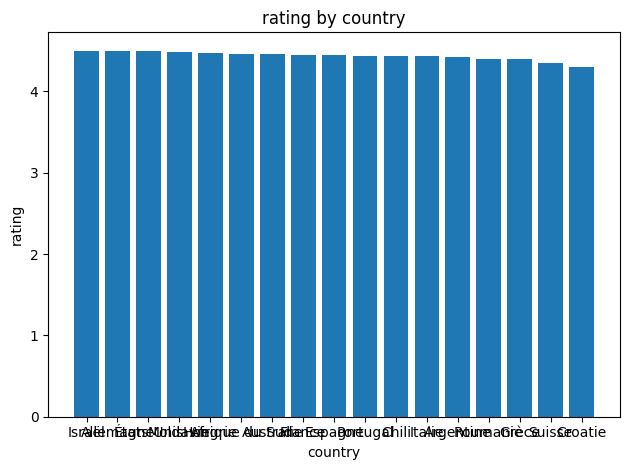

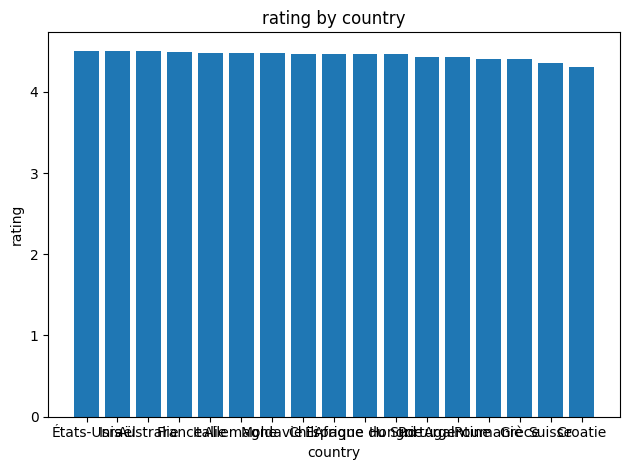

In [ ]:
import sqlite3
import matplotlib.pyplot as plt

# Connect to (or create) SQLite database file
conn = sqlite3.connect('vivino.db')
cursor = conn.cursor()

# Read SQL file
with open('queries.sql', 'r') as f:
    lines = f.readlines()

# Remove comment lines starting with --
lines_clean = [line for line in lines if not line.strip().startswith('--')]

sql_script_clean = ''.join(lines_clean)

# Then split by semicolon to get individual queries
queries = [q.strip() for q in sql_script_clean.split(';') if q.strip()]

for query in queries:
    cursor.execute(query)
    
    # cursor.description is None if no results returned
    if cursor.description is not None:
        rows = cursor.fetchall()
        columns = [desc[0] for desc in cursor.description]

        # Print query and results
        print(f"Query:\n{query}\n")
        print('\t'.join(columns))
        for row in rows:
            print('\t'.join(str(cell) for cell in row))
        print('\n' + '-'*40 + '\n')
    else:
        # No result set returned (e.g., INSERT, UPDATE)
        print(f"Query executed (no rows returned):\n{query}\n")

# Execute last two queries
for query in queries[-2:]:
    cursor.execute(query)
    results = cursor.fetchall()
    columns = [desc[0] for desc in cursor.description]

    x_vals = [row[0] for row in results]
    y_vals = [row[1] for row in results]

    plt.bar(x_vals, y_vals)
    plt.xlabel('country')
    plt.ylabel('rating')
    plt.title('rating by country')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

cursor.close()
conn.close()

In [5]:
query = 'SELECT * FROM wines LIMIT 5;'
cursor.execute(query)

for row in cursor.fetchall():
    print(row)

(1213, 'Vin Santo di Montepulciano', 0, 2693, 1574, 4.6, 773, 'https://www.seulementproduitsitaliens.be/spec_collezioni.php?CODICEWT=10AVVS92H', 4.492628, None, 3.9921334, 4.952543, None, 0)
(1268, 'St. Henri Shiraz', 0, 7, 1305, 4.4, 17326, 'https://www.wijnig.nl/penfolds-st-henri-shiraz-2018.html', 3.0152445, None, 4.612774, 2.092192, 3.1030886, 1309)
(1471, 'Siepi', 0, 394, 1620, 4.4, 8129, 'https://www.topwijnen.be/nl/product/wijnen/italie/toscane/igt-toscane/wn6010264/wn6010264', 3.156144, None, 3.4918664, 1.807986, 2.9856336, 755)
(1647, 'Solare Toscana', 0, 394, 4772, 4.2, 4961, 'https://www.seulementproduitsitaliens.be/spec_collezioni.php?CODICE=2001658', 3.1583757, None, 3.3216164, 1.7018968, 3.0380645, 485)
(1651, "Tenuta Tignanello 'Solaia'", 0, 394, 1252, 4.6, 33143, 'http://www.vivino.com/wines/159347388', 3.0641637, None, 3.4507132, 1.8885487, 2.9705827, 2131)
